In [24]:
# this project demonstrates how to use langgraph to create a conditional workflow with LLMs. The workflow is a simple review system that takes a review as input and returns the sentiment of the review and a diagnosis of the review. The workflow is designed to be iterative, meaning that if the sentiment is negative, the workflow will ask for a new review until the sentiment is positive or the maximum number of iterations is reached.
from langgraph.graph import StateGraph, START, END
from langchain_anthropic import ChatAnthropic
from dotenv import load_dotenv
from typing import TypedDict, Annotated,Literal
from pydantic import BaseModel, Field
import operator
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage

In [25]:
blog_generator_optimizer_llm = ChatAnthropic(model="claude-sonnet-5")
blog_evaluator_llm = ChatAnthropic(model="claude-opus-5")


In [27]:
class TweetState(TypedDict):
    topic: str
    blog: str
    evaluation: Literal['approved', 'needs improvement']
    feedback: str
    iteration: int
    max_iteration: int

In [28]:
class evaluationSchema(BaseModel):
    evaluation: Literal['approved', 'needs improvement']=Field(description='The evaluation of the blog, which can be approved or needs improvement.')
    feedback: str=Field(description='The feedback for the blog, which can be any string.')

In [29]:
structured_blog_evaluator_llm = blog_evaluator_llm.with_structured_output(evaluationSchema)

In [46]:
def make_blog(state: TweetState):
    prompt = f"""
Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

Rules:
- Do NOT use question-answer format.
- Max 280 characters.
- Use observational humor, irony, sarcasm, or cultural references.
- Think in meme logic, punchlines, or relatable takes.
- Use simple, day to day english
"""
    blog = (blog_generator_optimizer_llm.invoke(prompt).content)
    return {'blog': blog}


In [47]:


def evaluate_blog(state: TweetState):
    prompt = f"""
Evaluate the following tweet:

Tweet: "{state['blog']}"

Use the criteria below to evaluate the tweet:

1. Originality – Is this fresh, or have you seen it a hundred times before?  
2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
3. Punchiness – Is it short, sharp, and scroll-stopping?  
4. Virality Potential – Would people retweet or share it?  
5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

Auto-reject if:
- It's written in question-answer format (e.g., "Why did..." or "What happens when...")
- It exceeds 280 characters
- It reads like a traditional setup-punchline joke
- Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

### Respond ONLY in structured format:
- evaluation: "approved" or "needs_improvement"  
- feedback: One paragraph explaining the strengths and weaknesses 
"""
    response = structured_blog_evaluator_llm.invoke(prompt)
    return {'evaluation': response.evaluation, 'feedback': response.feedback}

def improve_blog(state: TweetState):
    prompt = f"""
Improve the tweet based on this feedback:
"{state['feedback']}"

Topic: "{state['topic']}"
Original Tweet:
{state['blog']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
"""
    improved_blog = blog_generator_optimizer_llm.invoke(prompt).content
    iteration = state['iteration'] + 1
    return {'blog': improved_blog, 'iteration': iteration}

In [49]:
def conditional_loop(state: TweetState):
    if state['evaluation'] == 'needs improvement' and state['iteration'] < state['max_iteration']:
        return 'improve_blog'
    else:
        return END

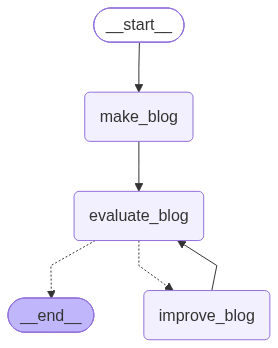

In [50]:
graph = StateGraph(TweetState)

graph.add_node('make_blog',make_blog)
graph.add_node('evaluate_blog',evaluate_blog)
graph.add_node('improve_blog',improve_blog)

graph.add_edge(START, 'make_blog')
graph.add_edge('make_blog', 'evaluate_blog')
graph.add_conditional_edges('evaluate_blog', conditional_loop,{'improve_blog': 'improve_blog', END: END})
graph.add_edge('improve_blog', 'evaluate_blog')


workflow=graph.compile()

workflow

In [52]:
workflow.invoke({
    'topic':'the indian economy',
    'iteration': 1,
    'max_iteration': 3
})

{'topic': 'the indian economy',
 'blog': "Indian economy be like: GDP growing 7%, but my uncle still thinks the real indicator is how many people showed up at his daughter's wedding buffet.",
 'evaluation': 'approved',
 'feedback': 'This tweet clears all the auto-reject gates cleanly: it\'s a single-sentence observational quip rather than a Q&A or setup-punchline structure, it sits comfortably under 280 characters, and it ends on the strongest image ("wedding buffet") instead of trailing off into a generic summary line. Originality is solid — the "GDP vs. desi uncle\'s personal metrics" contrast is a familiar territory, but the specific pivot to wedding buffet headcount as an alternative economic index is a fresh, well-chosen detail rather than a recycled auntie-uncle cliché. Humor lands through specificity and recognition; the "Indian economy be like" opener gives it a casual, meme-native voice that earns a genuine chuckle. Punchiness is good, though the sentence is slightly front-loa